In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import pickle

In [2]:
loan_df=pd.read_csv("loan_approval_data.csv")

# BASIC INFO OF DATASET

In [3]:
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
loan_df.isna().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# HANDLING MISSING VALUES

In [6]:
categorial_cols=loan_df.select_dtypes(include='object').columns
numerical_cols=loan_df.select_dtypes(include='number').columns

In [7]:
categorial_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [8]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [9]:
num_imp = SimpleImputer(missing_values=np.nan, strategy='mean')
loan_df[numerical_cols]=num_imp.fit_transform(loan_df[numerical_cols])

In [10]:
cat_imp= SimpleImputer(missing_values=np.nan, strategy='most_frequent')
loan_df[categorial_cols]=cat_imp.fit_transform(loan_df[categorial_cols])

In [11]:
loan_df.isna().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA- Exploratory Data Analysis

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


Text(0.5, 1.0, 'Is Loan approved or not?')

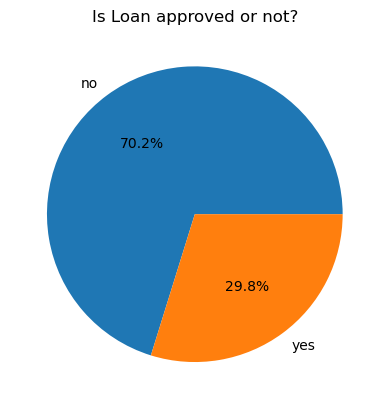

In [12]:
# how balanced our output classes are?
classes_count=loan_df["Loan_Approved"].value_counts()
print(classes_count)
plt.pie(classes_count,labels=["no","yes"],autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

# we observed majority of loan applications are rejected which happens in real world as well

In [13]:
categorial_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

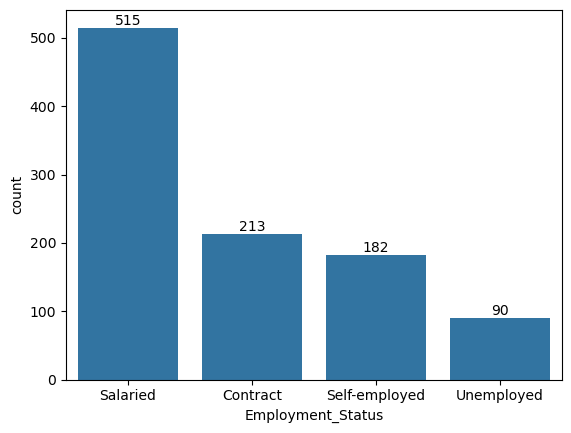

In [14]:
#Analysing categories
emp_cnt=loan_df["Employment_Status"].value_counts()
ax=sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

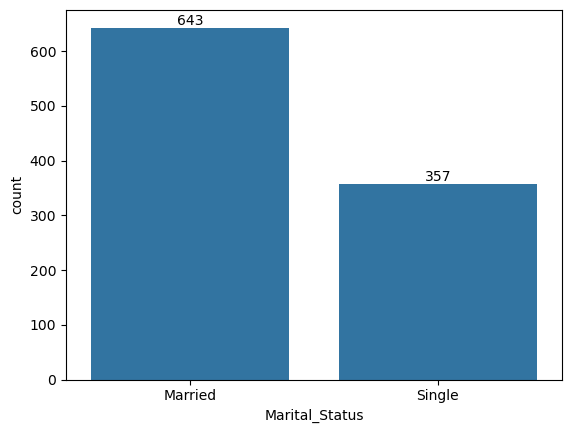

In [15]:
mar_cnt=loan_df["Marital_Status"].value_counts()
ax=sns.barplot(mar_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

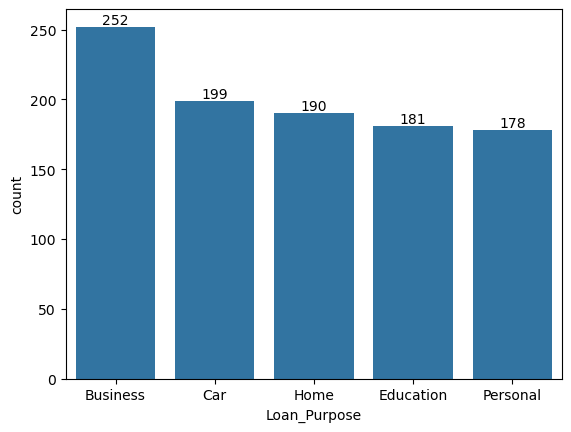

In [16]:
pur_cnt=loan_df["Loan_Purpose"].value_counts()
ax=sns.barplot(pur_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

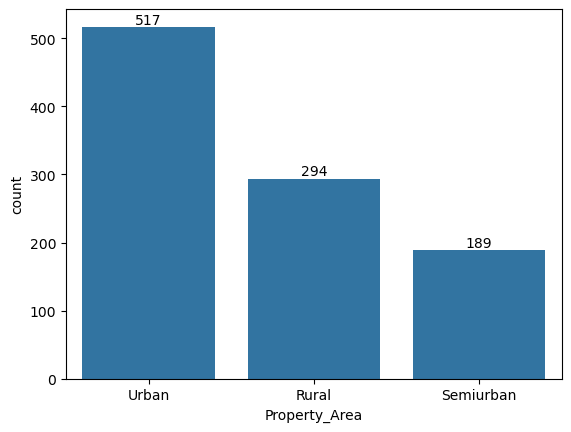

In [17]:
prop_cnt=loan_df["Property_Area"].value_counts()
ax=sns.barplot(prop_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

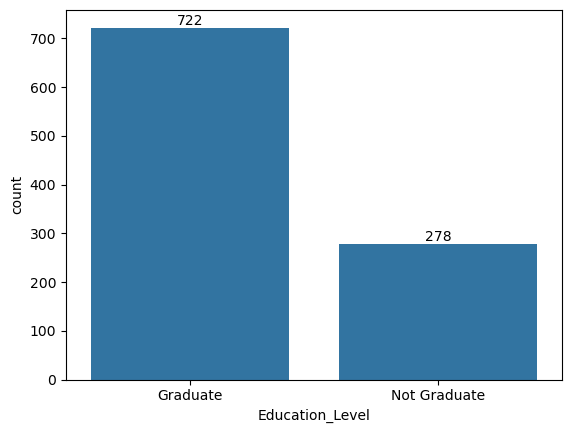

In [18]:
edu_cnt=loan_df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '621'), Text(0, 0, '379')]

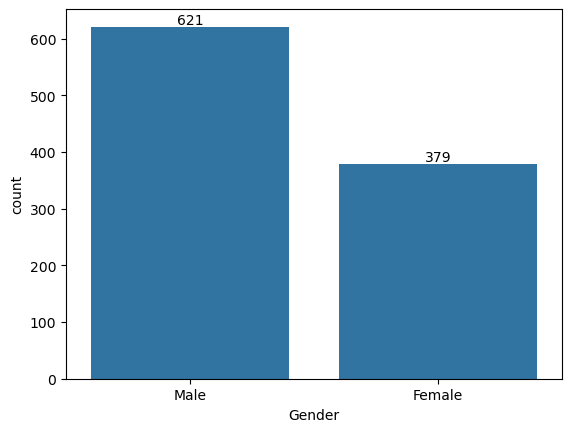

In [19]:
gen_cnt=loan_df["Gender"].value_counts()
ax=sns.barplot(gen_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

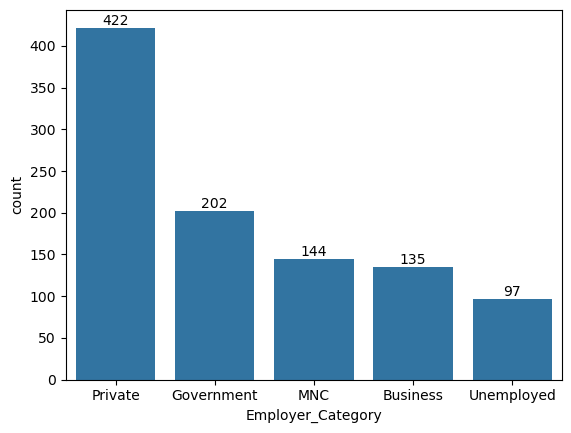

In [20]:
emp_cat_cnt=loan_df["Employer_Category"].value_counts()
ax=sns.barplot(emp_cat_cnt)
ax.bar_label(ax.containers[0])

In [21]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [22]:
categorial_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

<Axes: xlabel='Applicant_Income', ylabel='Count'>

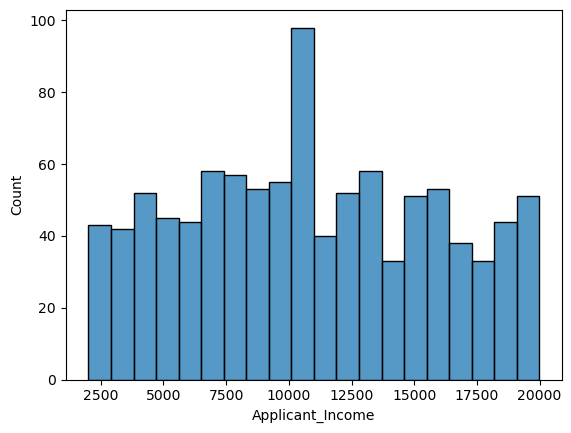

In [23]:
#analysing income
sns.histplot(
    data=loan_df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

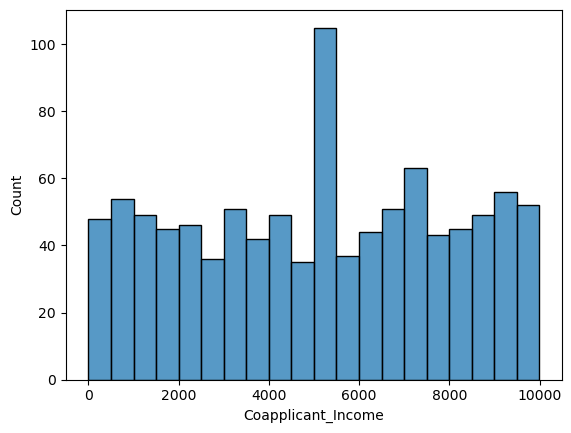

In [24]:
sns.histplot(
    data=loan_df,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

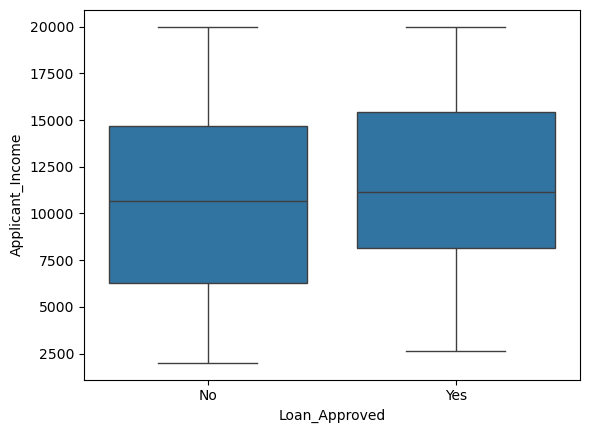

In [25]:
#boxplot to detect outliers
sns.boxplot(
    data=loan_df,
    x="Loan_Approved",
    y="Applicant_Income"
)

# we saw there is not outlier in income for both where loan is approved and where loan is not approved
#income might be one factor ,we saw loan is approved where income is more as compared to there where  income is low

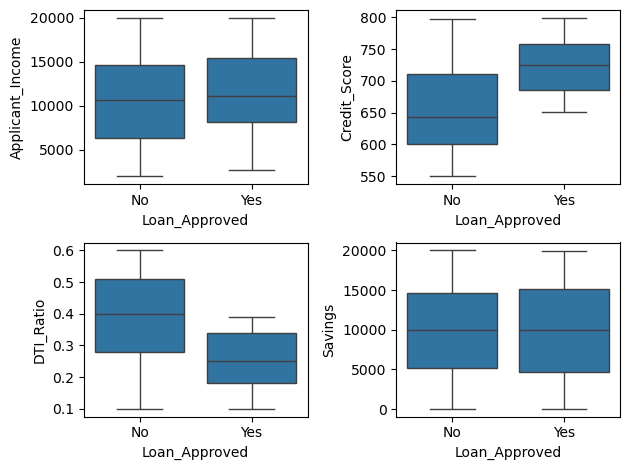

In [26]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=loan_df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=loan_df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=loan_df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=loan_df,x="Loan_Approved",y="Savings")
plt.tight_layout()

In [27]:
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


<Axes: xlabel='Credit_Score', ylabel='Count'>

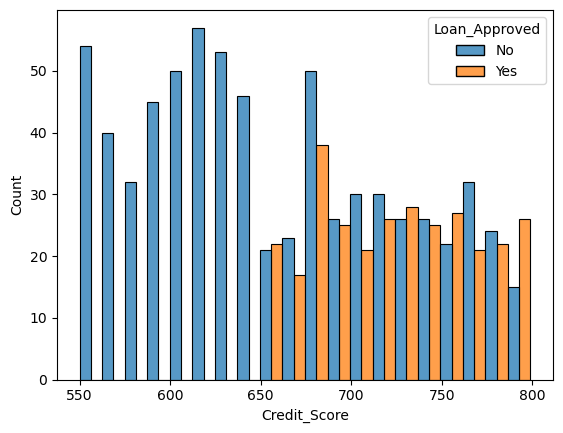

In [28]:
#credit store with loan approved
sns.histplot(
    data=loan_df,
    x="Credit_Score",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)
# we se3 person having higher credit score got more loan approval than the person having lower credit score

<Axes: xlabel='Applicant_Income', ylabel='Count'>

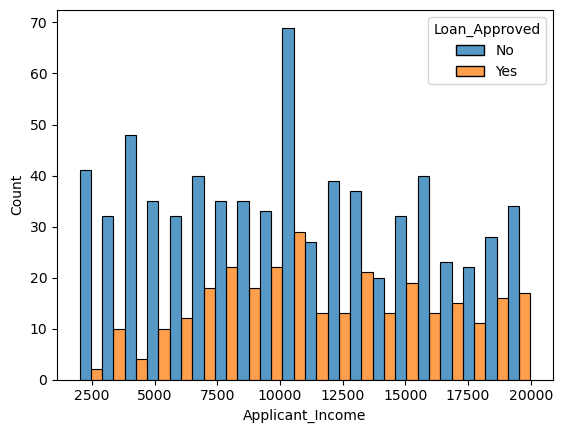

In [29]:
sns.histplot(
    data=loan_df,
    x="Applicant_Income",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)
#no pattern observed here

In [30]:
#remove the applicant id
loan_df=loan_df.drop("Applicant_ID",axis=1)

In [31]:
loan_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding

In [32]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [33]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

In [34]:
le=LabelEncoder()
loan_df["Education_Level"]=le.fit_transform(loan_df["Education_Level"])
loan_df["Loan_Approved"]=le.fit_transform(loan_df["Loan_Approved"])

In [35]:
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(loan_df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(),index=loan_df.index)
loan_df=pd.concat([loan_df.drop(columns=cols),encoded_df],axis=1)

In [36]:
loan_df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

<Axes: >

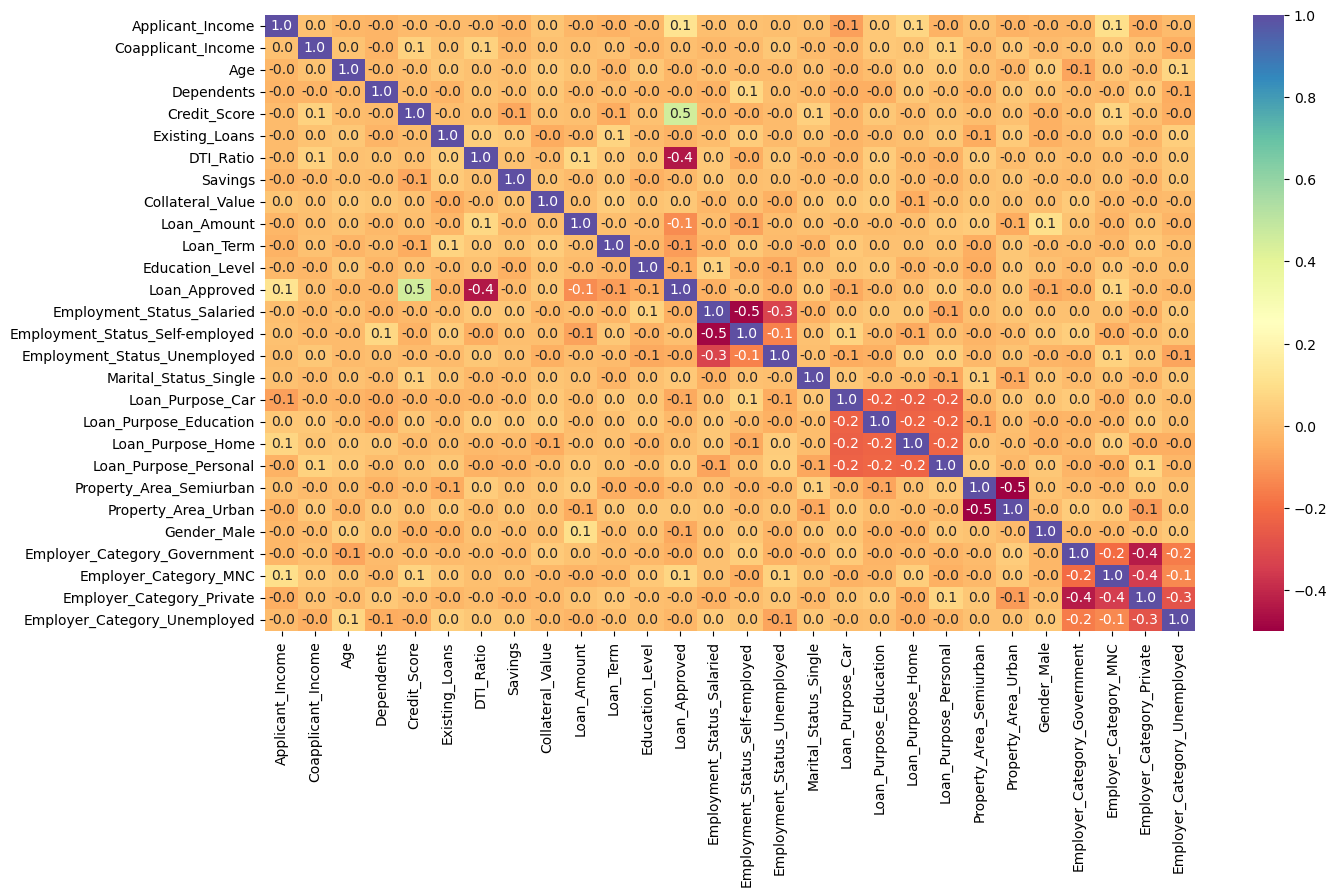

In [37]:
nums_cols=loan_df.select_dtypes(include='number')
corr_matrix=nums_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="Spectral"
)

In [38]:
nums_cols.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [39]:
corr_matrix["Loan_Approved"].sort_values(ascending=False)

# We observed from below that greater the credit greater the chances of loan approval same can be seen below
#Similarly can be concluded for applicant_income

#we also observed greater the DTI_Ratio less the chances of loan approval
#We also observed greater the loan_amount less the chances of Loan approval

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-Test-Split + Feature Scaling

In [40]:
X=loan_df.drop("Loan_Approved",axis=1)
y=loan_df["Loan_Approved"]

In [41]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [42]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
scaler=StandardScaler()

In [45]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Training And Evaluating using Diffrent Models

In [46]:
#logistic Regression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred1=log_model.predict(X_test_scaled)

In [47]:
cm=confusion_matrix(y_test,y_pred1)
print("Accuracy_score:",accuracy_score(y_test,y_pred1))
print("precision_score:",precision_score(y_test,y_pred1))
print("recall_score:",recall_score(y_test,y_pred1))
print("f1_score:",f1_score(y_test,y_pred1))

Accuracy_score: 0.865
precision_score: 0.7833333333333333
recall_score: 0.7704918032786885
f1_score: 0.7768595041322314


<Axes: >

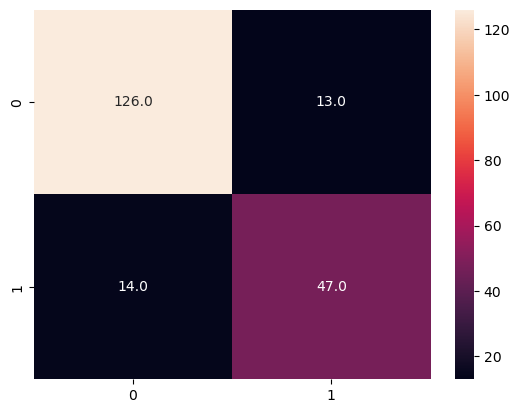

In [48]:
sns.heatmap(
    data=cm,
    annot=True,
    fmt="0.1f"
)

In [49]:
#KNN

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred2=knn_model.predict(X_test_scaled)


In [50]:
cm1=confusion_matrix(y_test,y_pred2)
print("Accuracy_score:",accuracy_score(y_test,y_pred2))
print("precision_score:",precision_score(y_test,y_pred2))
print("recall_score:",recall_score(y_test,y_pred2))
print("f1_score:",f1_score(y_test,y_pred2))

Accuracy_score: 0.76
precision_score: 0.6274509803921569
recall_score: 0.5245901639344263
f1_score: 0.5714285714285714


<Axes: >

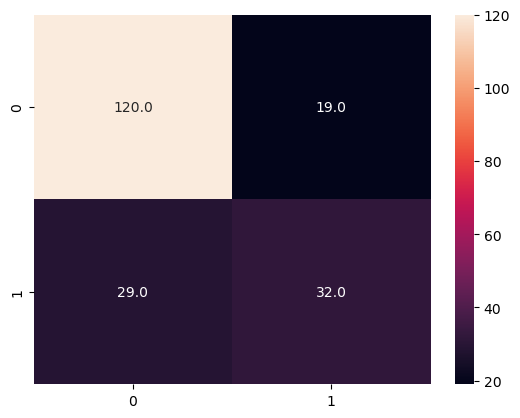

In [51]:
sns.heatmap(
    data=cm1,
    annot=True,
    fmt="0.1f"
)

In [52]:
# Naive Bayes
gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)
y_pred3=gnb_model.predict(X_test_scaled)


In [53]:
cm2=confusion_matrix(y_test,y_pred3)
print("Accuracy_score:",accuracy_score(y_test,y_pred3))
print("precision_score:",precision_score(y_test,y_pred3))
print("recall_score:",recall_score(y_test,y_pred3))
print("f1_score:",f1_score(y_test,y_pred3))

Accuracy_score: 0.865
precision_score: 0.8035714285714286
recall_score: 0.7377049180327869
f1_score: 0.7692307692307693


<Axes: >

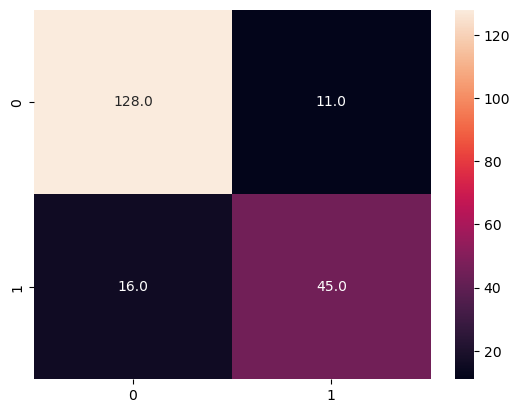

In [54]:
sns.heatmap(
    data=cm2,
    annot=True,
    fmt="0.1f"
)

# Currently best model on basis of prediction ->Naive Bayes

# Feature Engineering

In [55]:
loan_df["DTI_Ratio_sq"]=loan_df["DTI_Ratio"]**2
loan_df["Credit_Score_sq"]=loan_df["Credit_Score"]**2

loan_df["Applicant_Income_log"]=np.log1p(loan_df["Applicant_Income"])

X=loan_df.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved"])
y=loan_df["Loan_Approved"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [56]:
gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)
y_pred3=gnb_model.predict(X_test_scaled)

In [57]:
cm2=confusion_matrix(y_test,y_pred3)
print("Accuracy_score:",accuracy_score(y_test,y_pred3))
print("precision_score:",precision_score(y_test,y_pred3))
print("recall_score:",recall_score(y_test,y_pred3))
print("f1_score:",f1_score(y_test,y_pred3))

Accuracy_score: 0.86
precision_score: 0.8113207547169812
recall_score: 0.7049180327868853
f1_score: 0.7543859649122807
